In [1]:
%cd ../../

/Users/hoangle/Projects/untangling-people/ylva/fwo_models


In [34]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import polars as pl
import holidays
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from pytorch_lightning.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger
from sklearn.metrics import mean_absolute_percentage_error
from darts.models import CatBoostModel, TFTModel, TransformerModel, TSMixerModel, RNNModel, XGBModel, LightGBMModel, NBEATSModel
from sklearn.preprocessing import MinMaxScaler

In [3]:
EPS = 1e-6

In [4]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Read and process data

In [5]:
path = "data/processed/waste.parquet"

waste = pl.read_parquet(path)
waste.head()

id,date,restaurant,waste,src
str,date,i64,f32,str
"""2024-11-01|3""",2024-11-01,3,19.0,"""Data Physicum 01112024-3103202…"
"""2024-11-04|3""",2024-11-04,3,21.0,"""Data Physicum 01112024-3103202…"
"""2024-11-05|3""",2024-11-05,3,15.0,"""Data Physicum 01112024-3103202…"
"""2024-11-06|3""",2024-11-06,3,15.0,"""Data Physicum 01112024-3103202…"
"""2024-11-07|3""",2024-11-07,3,15.0,"""Data Physicum 01112024-3103202…"


In [6]:
path = "data/processed/dim_restaurants.xlsx"
dim_restaurants = pl.read_excel(path)

dim_restaurants.head()

restaurant_id,restaurant,restaurant_short
i64,str,str
1,"""600 Chemicum""","""che"""
2,"""620 Exactum""","""exa"""
3,"""610 Physicum""","""phy"""
4,"""570 Viikuna""","""vik"""


## Process

In [21]:
waste_daily = (
    waste
    .drop('id', 'src')

    .join(
        dim_restaurants.select('restaurant_id', 'restaurant_short'),
        left_on='restaurant',
        right_on='restaurant_id',
        how='left'
    )
    .drop('restaurant')
    .rename({'restaurant_short': 'restaurant'})   


    # Add small amount for training stability
    .with_columns(
        pl.col('waste') + EPS
    )


    # Pivot
    .pivot(index='date', on='restaurant', values='waste')
    .sort('date')

)


# Make new dataframe only containing entries of weekdays
waste_daily = (
    pl.DataFrame({
        'date': pl.Series(pd.date_range(waste['date'].min(), waste['date'].max(), freq='B')).cast(pl.Date)
    })

    .join(waste_daily, on='date', how='left')

    .fill_null(EPS)
)


waste_daily.head()

date,phy,vik,exa,che
date,f32,f32,f32,f32
2023-01-02,1.0000e-6,1.0000e-6,1.0000e-6,17.900002
2023-01-03,1.0000e-6,1.0000e-6,1.0000e-6,21.200003
2023-01-04,1.0000e-6,1.0000e-6,1.0000e-6,15.250001
2023-01-05,1.0000e-6,1.0000e-6,1.0000e-6,21.800001
2023-01-06,1.0000e-6,1.0000e-6,1.0000e-6,1.0000e-6


<Axes: xlabel='date'>

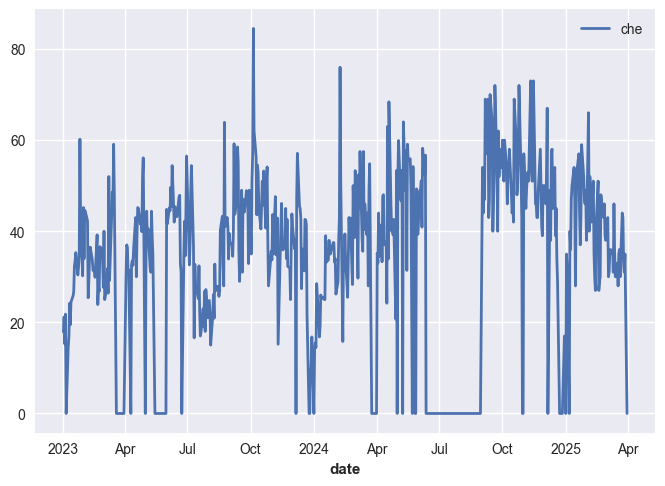

In [22]:
restaurant = "che"

series = (
    TimeSeries
    .from_dataframe(
        waste_daily.to_pandas(),
        time_col='date',
        value_cols=[
            restaurant
            # 'che',
            # 'exa',
            # 'phy',
            # 'vik'
        ],
        fillna_value=EPS,
        freq='B',
    )
)

series.plot()

## Tailor other dimensions

<Axes: xlabel='date'>

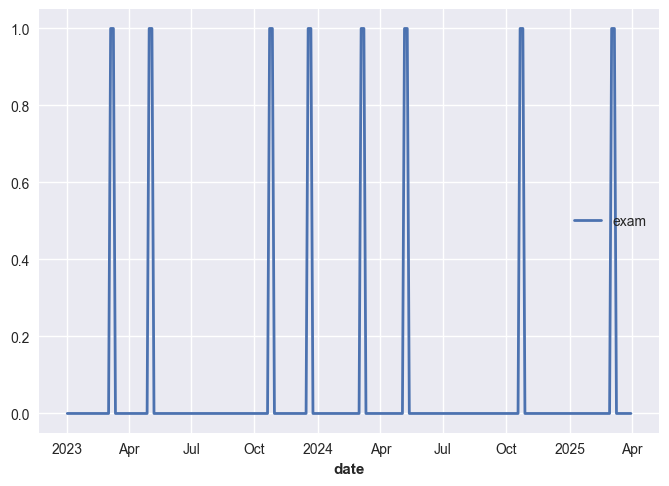

In [24]:
dim_exam = (
    pl
    .from_records([
        {'date_begin': '2023-03-06', 'date_end': '2023-03-12'},  
        {'date_begin': '2023-05-01', 'date_end': '2023-05-07'},
        {'date_begin': '2023-10-23', 'date_end': '2023-10-29'},
        {'date_begin': '2023-12-18', 'date_end': '2023-12-24'},
        {'date_begin': '2024-03-04', 'date_end': '2024-03-10'},
        {'date_begin': '2024-05-06', 'date_end': '2024-05-12'},
        {'date_begin': '2024-10-21', 'date_end': '2024-10-27'},
        {'date_begin': '2025-03-03', 'date_end': '2025-03-09'},
    ])
    .with_columns(
        pl.col('date_begin').str.to_date(),
        pl.col('date_end').str.to_date(),
    )
)

df = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(series.time_index.min(), series.time_index.max(), '1d').alias('date')
    )
)

entries_exam = (
    df
    .join(dim_exam, how='cross')
    .filter(
        (pl.col('date') >= pl.col('date_begin'))
        & (pl.col('date') <= pl.col('date_end'))
    )
    .select(
        'date',
        pl.lit(1).alias('exam')
    )
)
cov_exam = (
    df
    .join(entries_exam, on='date', how='left')
    .with_columns(
        pl
        .col('exam')
        .fill_null(0)
        .cast(pl.String())
        .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)


series_exam = (
    TimeSeries
    .from_dataframe(
        df=cov_exam.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='exam'
    )
    # .astype(np.float32)
)
series_exam.plot()

<Axes: xlabel='date'>

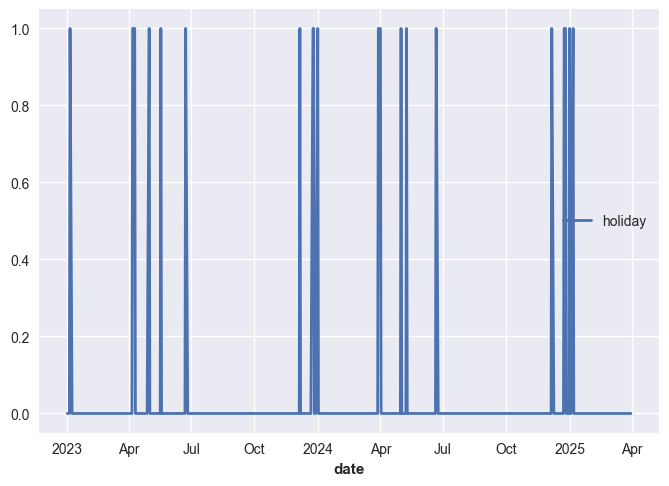

In [25]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])

cov_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(series.time_index.min(), series.time_index.max(), '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('holiday'))
    .drop('name_holiday')


    # Cast to categorical type
    .with_columns(
        pl
        .col('holiday')
        # .cast(pl.String())
        # .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

series_holiday = (
    TimeSeries
    .from_dataframe(
        df=cov_holiday.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='holiday'
    )
    # .astype(np.float32)
)
series_holiday.plot()


# Build forecasting model

In [ ]:
CUTOFF_DATE = pd.to_datetime("2025-01-01")
series_train, series_test = series.astype(np.float32).split_before(CUTOFF_DATE)

series_cov = (
    series_exam
    .concatenate(series_holiday, axis=1)
    .astype(np.float32)
)

<Axes: xlabel='date'>

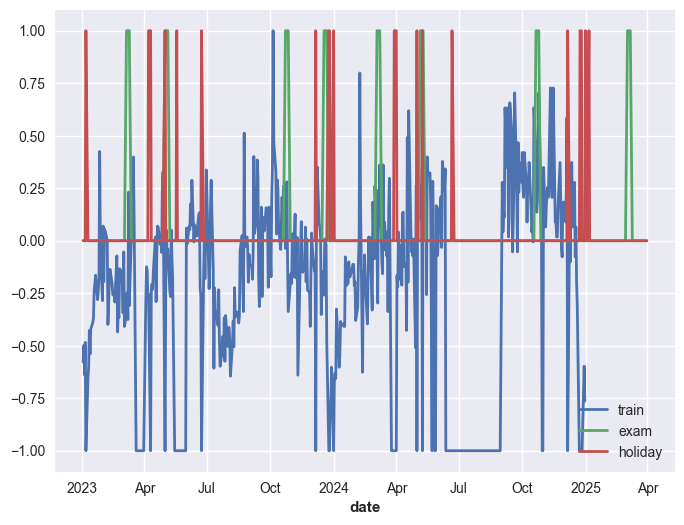

In [30]:
# transformer = Diff(1, dropna=True)
# series_transformed = transformer.fit_transform(series)
# series_train_diff = series_transformed.drop_after(CUTOFF_DATE)


series_train_transformed = series_train
# series_train_transformed = series_train_diff

transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
# transformer_target = BoxCox(lmbda=0.)
series_train_transformed = transformer_target.fit_transform(series_train_transformed)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

series_train_transformed.plot(ax=ax, label='train')
series_cov.plot(ax=ax)

## Models

In [37]:
version = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
model_name = "transformer"

input_chunk_length = 40
output_chunk_length = 30
num_epochs = 500


# Define params
add_encoders = {
    "datetime_attribute": {
        "future": ["dayofweek", 'day', 'month'],
        "past": ["dayofweek", 'day', 'month']
    },
    'cyclic': {
        'past': ["dayofweek", 'day', 'month'],
        'future': ["dayofweek", 'day', 'month']
    },
}

params_ml = {
    "lags": input_chunk_length,
    "lags_future_covariates": [0],
    "output_chunk_length": output_chunk_length,
    "add_encoders": {**add_encoders}
}
params_dl = {
    "input_chunk_length": input_chunk_length,
    "output_chunk_length": output_chunk_length,
    "add_encoders": {**add_encoders},  
    "n_epochs": num_epochs,
    "pl_trainer_kwargs": {
        "callbacks": [TQDMProgressBar(refresh_rate=4)],
        "logger": [
            TensorBoardLogger("logs/tensorboard", name=f"{model_name}-{restaurant}", version=version, default_hp_metric=False)
        ],
        'precision': "32-true",
    },
    "optimizer_kwargs": {
        'lr': 5e-4
    }
}

# Define models
match model_name:
    # =================================================
    # ML models
    # =================================================
    case "catboost":
        model = CatBoostModel(**params_ml)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "xgboost":
        model = XGBModel(**params_ml)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "lightbgm":
        model = LightGBMModel(**params_ml)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )

    # =================================================
    # DL models
    # =================================================
    case 'rnn':
        params_dl['model'] = 'LSTM'

        model = RNNModel(**params_dl)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "tsmixer":
        model = TSMixerModel(**params_dl)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "transformer":
        model = TransformerModel(**params_dl)
        model.fit(
            series_train_transformed,
            past_covariates=series_cov.split_before(CUTOFF_DATE)[0],
        )
    case "tft":
        params_dl["categorical_embedding_sizes"] = {
            "holiday": (2, 2),
            "exam": (2, 2),
            "restaurant": (4, 4)
        }

        model = TFTModel(**params_dl)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "n-beats":
        model = NBEATSModel(**params_dl)
        model.fit(
            series_train_transformed,
            past_covariates=series_cov.split_before(CUTOFF_DATE)[0],
        )
    
    case _:
        raise NotImplementedError()

Specified future encoders in `add_encoders` at model creation but model does not accept future covariates. future encoders will be ignored.
/Users/hoangle/Projects/untangling-people/ylva/fwo_models/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollection    | 0      | train
4 | val_metrics         | M

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


## Test

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hoangle/Projects/untangling-people/ylva/fwo_models/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |          | 0/? [00:00<?, ?it/s]

Text(0.5, 1.0, 'che | mape = 34.06%')

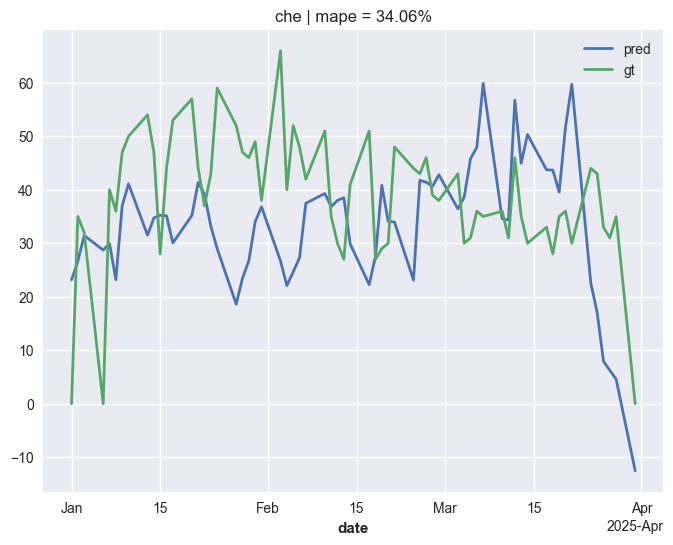

In [38]:
match model_name:
    # =================================================
    # ML models
    # =================================================
    case "catboost":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "xgboost":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "lightbgm":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )

    # =================================================
    # DL models
    # =================================================
    case "rnn":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "tsmixer":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "transformer":
        series_pred = model.predict(
            n=len(series_test),
            past_covariates=series_cov
        )
    case "transformer":
        series_pred = model.predict(
            n=len(series_test),
            past_covariates=series_cov
        )
    case "tft":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "n-beats":
        series_pred = model.predict(
            n=len(series_test),
            past_covariates=series_cov
        )

    case _:
        raise NotImplementedError()
    

series_pred = transformer_target.inverse_transform(series_pred)
# series_pred = transformer.inverse_transform(series_train_diff.concatenate(series_pred)).drop_before(CUTOFF_DATE)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
series_pred.plot(ax=ax, label='pred')
series_test.plot(ax=ax, label='gt')
# rmse_val = mape(series_test[comp], series_pred[comp])

df = pd.concat(
    [
        series_test.to_dataframe().rename(columns={restaurant: "gt"}),
        series_pred.to_dataframe().rename(columns={restaurant: "pred"})
    ],
    axis=1
)
df = df[df['gt'] > EPS]
mape_val = mean_absolute_percentage_error(df['gt'], df['pred'])

ax.set_title(f"{restaurant} | mape = {mape_val*100:.4}%")